# LangGraph Memory 示範

這份 notebook 使用 `MemorySaver` 儲存對話狀態。只要使用相同的 `thread_id`，LLM 就能讀到先前的訊息；不同的 `thread_id` 則會擁有彼此獨立的記憶。

## 1. Import libraries

In [1]:
import os

from IPython.display import Image, display
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState, StateGraph, START, END

## 2. 建立 LLM

請先在系統環境變數中設定 `OPENAI_API_KEY`。如果課程環境使用自訂 API endpoint，也可以設定 `OPENAI_BASE_URL`。

In [2]:
llm_options = {
    "api_key": os.environ["OPENAI_API_KEY"],
    "model": os.getenv("OPENAI_MODEL", "gpt-4o-mini"),
    "temperature": 0.0,
}

# 如果有設定自訂 endpoint，就將它加入 ChatOpenAI 的參數。
if os.getenv("OPENAI_BASE_URL"):
    llm_options["base_url"] = os.getenv("OPENAI_BASE_URL")

llm = ChatOpenAI(**llm_options)

## 3. 建立具有記憶功能的 LangGraph

`MessagesState` 會累積訊息；`MemorySaver` 則依照 `thread_id` 保存每次執行後的 checkpoint。

In [3]:
def chatbot(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}


workflow = StateGraph(MessagesState)
workflow.add_node("chatbot", chatbot)
workflow.add_edge(START, "chatbot")
workflow.add_edge("chatbot", END)

memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)

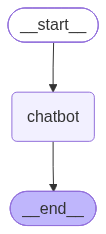

In [4]:
display(Image(graph.get_graph().draw_mermaid_png()))

## 4. 準備對話函式

每次只傳入最新問題。過去的訊息不需要由我們手動重傳，checkpointer 會根據 `thread_id` 自動取回。

In [5]:
def ask(question: str, thread_id: str = "demo-user") -> str:
    config = {"configurable": {"thread_id": thread_id}}
    result = graph.invoke(
        {"messages": [HumanMessage(content=question)]},
        config=config,
    )
    answer = result["messages"][-1].content
    print(f"You: {question}\nAI: {answer}")
    return answer

## 5. 測試：讓 LLM 記住先前說過的內容

In [6]:
ask("請記住：我的名字是小明，我最喜歡的寶可夢是皮卡丘。", thread_id="conversation-1")

You: 請記住：我的名字是小明，我最喜歡的寶可夢是皮卡丘。
AI: 好的，小明！我會記住你最喜歡的寶可夢是皮卡丘。如果你有任何問題或想聊的話，隨時告訴我！


'好的，小明！我會記住你最喜歡的寶可夢是皮卡丘。如果你有任何問題或想聊的話，隨時告訴我！'

In [7]:
# 沒有再次提供名字與寶可夢，模型仍可從同一個 thread 的記憶回答。
ask("我剛才說我的名字是什麼？最喜歡的寶可夢又是誰？", thread_id="conversation-1")

You: 我剛才說我的名字是什麼？最喜歡的寶可夢又是誰？
AI: 你的名字是小明，你最喜歡的寶可夢是皮卡丘！如果還有其他想聊的，隨時告訴我！


'你的名字是小明，你最喜歡的寶可夢是皮卡丘！如果還有其他想聊的，隨時告訴我！'

## 6. 查看記憶體中的訊息

可以直接讀取目前 checkpoint，確認 `conversation-1` 已保存完整對話。

In [8]:
config_1 = {"configurable": {"thread_id": "conversation-1"}}
current_state = graph.get_state(config_1)

for message in current_state.values["messages"]:
    print(f"{message.type}: {message.content}")

human: 請記住：我的名字是小明，我最喜歡的寶可夢是皮卡丘。
ai: 好的，小明！我會記住你最喜歡的寶可夢是皮卡丘。如果你有任何問題或想聊的話，隨時告訴我！
human: 我剛才說我的名字是什麼？最喜歡的寶可夢又是誰？
ai: 你的名字是小明，你最喜歡的寶可夢是皮卡丘！如果還有其他想聊的，隨時告訴我！


## 7. 對照：不同 thread 不共享記憶

下面改用全新的 `conversation-2`。因為它沒有前面的 checkpoint，模型應該不知道使用者的名字與喜好。

In [9]:
ask("我的名字是什麼？我最喜歡哪一隻寶可夢？", thread_id="conversation-2")

You: 我的名字是什麼？我最喜歡哪一隻寶可夢？
AI: 抱歉，我無法知道你的名字或你最喜歡的寶可夢。如果你願意，可以告訴我你的名字和喜歡的寶可夢，我會很高興地和你聊聊！


'抱歉，我無法知道你的名字或你最喜歡的寶可夢。如果你願意，可以告訴我你的名字和喜歡的寶可夢，我會很高興地和你聊聊！'

## 重點整理

- 相同 `thread_id`：延續先前訊息，適合多輪對話。
- 不同 `thread_id`：各自保存狀態，可隔離不同使用者或不同對話。
- `MemorySaver` 只保存在目前 Python 程序的記憶體中；kernel 重啟後資料就會消失。正式系統可改用資料庫型 checkpointer，讓記憶持久保存。